# Analisi preliminare referti annotati reali

# Preliminari

In [79]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import ast
from pprint import pprint

In [80]:
# set plot style
plt.style.use('ggplot')

# Load Data

In [81]:
# Get data

data_path = Path('../data/base.tumoreprimitivo.csv/')
# Se il file non è presente, inserirlo manualmente prendendolo dalla cartella dropbox

data = pd.read_csv(data_path)

In [82]:
# Refert poco chiari
for i, r in data[data['interpretazioni'].str.contains("escludere", case=False, na=False)].iterrows():
    print(f"*--- id referto: {r['id']}\ninterpretazione: {r['interpretazioni']}\n{100*'-'}")

*--- id referto: 259
interpretazione: POCHE INFO; FORSE DA ESCLUDERE

55 mm che misura è? 
credo possa riferirsi a diametro assiale massimo
----------------------------------------------------------------------------------------------------
*--- id referto: 171
interpretazione: FORSE DA ESCLUDERE; REFERTO NON CHIARO

la formazione nodulare è digitazione della neoplasia o linfonodo? in base a questo va compilato. 

non si può sapere se non rivedendo immagini, anche per linfonodi non è chiaro se sono sospetti o no, 
----------------------------------------------------------------------------------------------------


In [83]:
print(f'{data.shape = }')
display(data.head(3))
display(data.head(1).T)

data.shape = (308, 45)


,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,387,PietroPaoloAzzaro,['nessuna'],nessuna,NaN,27975580,M,1949-11-07,NaN,RM ADDOME INFERIORE (S/C MDC)\nESAME ESEGUITO ...,...,si,NaN,0.0,False,"['mesorettali', 'mesenterici_inferiori']",[],NaN,0.0,no,incomplete
1,386,PietroPaoloAzzaro,['nessuna'],nessuna,NaN,43258300,F,1960-08-04,NaN,RM ADDOME INFERIORE (S/C MDC) STUDIO RM CONDOT...,...,NaN,NaN,0.0,True,"['mesorettali', 'mesenterici_inferiori']",[],NaN,0.0,no,incomplete
2,385,PietroPaoloAzzaro,['nessuna'],nessuna,NaN,43258300,F,1960-08-04,NaN,RM ADDOME INFERIORE (S/C MDC) STUDIO RM CONDOT...,...,si,NaN,0.0,True,"['mesorettali', 'mesenterici_inferiori']",[],NaN,0.0,no,incomplete


,0
id,387
profile,PietroPaoloAzzaro
discrepanze_rilevate,['nessuna']
motivazioni_discrepanze,nessuna
radiologist,NaN
patient_id,27975580
sesso,M
data_nascita,1949-11-07
interpretazioni,NaN
report_text,RM ADDOME INFERIORE (S/C MDC)\nESAME ESEGUITO ...


In [84]:
data[data['id'] == 262][['numero_linfonodi_non_conosciuto', 'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali']]

,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_locoregionali,sedi_non_locoregionali
110,False,3.0,"['mesorettali', 'rettali_superiori']",[]


# Elimina righe doppie

In [85]:
print(f'Shape iniziale: {data.shape}')

# Intere righe duplicate. Keep last perchè i report hanno id decrescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')

# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
righe_report_duplicato = data_clean[duplicati]
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Shape iniziale: (308, 45)
Numero righe duplicate: 3
Righe doppie eliminate
Numero righe con stesso referto: 13
Righe eliminate
data_clean.shape = (292, 45)


In [86]:
# !!! anomalia
data_clean[
    (data_clean['numero_depositi'] < 0) &
    (data_clean['profile'] == 'GuidoImbemba')
    ][
         ['id', 'profile', 'depositi_tumorali', 'numero_depositi']
    ]

,id,profile,depositi_tumorali,numero_depositi
183,173,GuidoImbemba,no,-1.0
185,171,GuidoImbemba,no,-1.0
251,98,GuidoImbemba,no,-1.0
253,95,GuidoImbemba,no,-1.0


In [87]:
# Sostituiamo valore -1 con 0 per la colonna numero depositi
data_clean.loc[data_clean['numero_depositi'] == -1.0, 'numero_depositi'] = 0.0

In [88]:
# !!! anomalia
data_clean[
    (data_clean['linfonodi_sospetti'] == 0) &
    (data_clean['numero_linfonodi_non_conosciuto'] == False) &
    (data_clean['sedi_locoregionali'] != '[]')
    ][
         ['id', 'profile', 'numero_linfonodi_non_conosciuto', 'linfonodi_sospetti', 'sedi_locoregionali']
    ]

,id,profile,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_locoregionali
0,387,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori']"
4,382,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori']"
7,378,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori', 'ottu..."
10,375,PietroPaoloAzzaro,False,0.0,['mesorettali']
13,372,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'sacrali', 'mesenterici_inferi..."
14,371,PietroPaoloAzzaro,False,0.0,['mesorettali']
17,368,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori', 'ottu..."
27,358,PietroPaoloAzzaro,False,0.0,['mesorettali']
28,357,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori']"
29,356,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'mesenterici_inferiori']"


al momento non prendiamo contromisure, aspettiamo Ilaria, togliamo le righe

In [89]:
index_to_remove = data_clean[
    (data_clean['linfonodi_sospetti'] == 0) &
    (data_clean['numero_linfonodi_non_conosciuto'] == False) &
    (data_clean['sedi_locoregionali'] != '[]')
    ].index
print(index_to_remove)

Index([  0,   4,   7,  10,  13,  14,  17,  27,  28,  29,  37,  39,  46,  48,
        49,  51,  53,  54,  55,  60,  65,  69,  70,  71, 149, 219, 220, 221,
       222, 223, 224, 225, 228, 231, 243, 284],
      dtype='int64')


In [90]:
data_clean.drop(index=index_to_remove, inplace=True)
data_clean.reset_index(inplace=True, drop=True)
print(f'{data_clean.shape = }')

data_clean.shape = (256, 45)


In [91]:
# !!! anomalia
data_clean[
    (data_clean['infiltrazione_organi_dettagli'] > '') &
    (data_clean['infiltrazione_organi_extra'] == 'no')
    ][
        ['id', 'profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra']
    ]

,id,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra
16,362,PietroPaoloAzzaro,"{'altro': ""muscolo elevatore dell'ano"", 'pavim...",no
79,262,GuidoImbemba,{'altro': ''},no
87,254,GuidoImbemba,{'sacro': False},no
90,250,GuidoImbemba,{'sacro': False},no
144,195,PietroPaoloAzzaro,{'altro': 'lesioni secondarie al fegato'},no
164,167,GuidoImbemba,{'pavimento_pelvico': False},no
190,138,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
191,137,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
192,136,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
209,106,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no


In [92]:
# Sostituiamo i valore con None nella colonna dei dettagli degli organi coinvolti pechè altri valori non sono compatibili con "no" nella colonna infiltrazione_organi_extra
for i in range(data_clean.shape[0]):
    if (data_clean.loc[i, 'infiltrazione_organi_extra'] == 'no') and (data_clean.loc[i, 'infiltrazione_organi_dettagli'] is not None):
        data_clean.loc[i, 'infiltrazione_organi_dettagli'] = None

display(data_clean[(data_clean['infiltrazione_organi_dettagli'] > '') * (data_clean['infiltrazione_organi_extra'] == 'no')][['profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra']])

,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra


In [94]:
# creazione nuova colonna "sedi_linfonodi_sospetti"
sedi_linfonodi = []
for s1, s2 in zip(data_clean.sedi_locoregionali, data_clean.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data_clean['sedi_linfonodi'] = sedi_linfonodi
data_clean[['sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']].head(15)

,sedi_locoregionali,sedi_non_locoregionali,sedi_linfonodi
0,"['mesorettali', 'mesenterici_inferiori']",[],"['mesorettali', 'mesenterici_inferiori']"
1,"['mesorettali', 'otturatori']",[],"['mesorettali', 'otturatori']"
2,['mesenterici_inferiori'],[],['mesenterici_inferiori']
3,"['mesenterici_inferiori', 'mesorettali']",[],"['mesenterici_inferiori', 'mesorettali']"
4,['mesorettali'],[],['mesorettali']
5,"['mesorettali', 'otturatori', 'mesenterici_inf...",[],"['mesorettali', 'otturatori', 'mesenterici_inf..."
6,"['mesorettali', 'mesenterici_inferiori', 'sacr...",[],"['mesorettali', 'mesenterici_inferiori', 'sacr..."
7,"['mesorettali', 'mesenterici_inferiori']",[],"['mesorettali', 'mesenterici_inferiori']"
8,['mesorettali'],[],['mesorettali']
9,"['mesorettali', 'mesenterici_inferiori']",[],"['mesorettali', 'mesenterici_inferiori']"


# Analisi preliminari delle colonne

In [95]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      256 non-null    int64  
 1   profile                                 256 non-null    object 
 2   discrepanze_rilevate                    256 non-null    object 
 3   motivazioni_discrepanze                 256 non-null    object 
 4   radiologist                             2 non-null      object 
 5   patient_id                              256 non-null    int64  
 6   sesso                                   254 non-null    object 
 7   data_nascita                            255 non-null    object 
 8   interpretazioni                         77 non-null     object 
 9   report_text                             256 non-null    object 
 10  morfologia                              246 non-null    object

In [96]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)

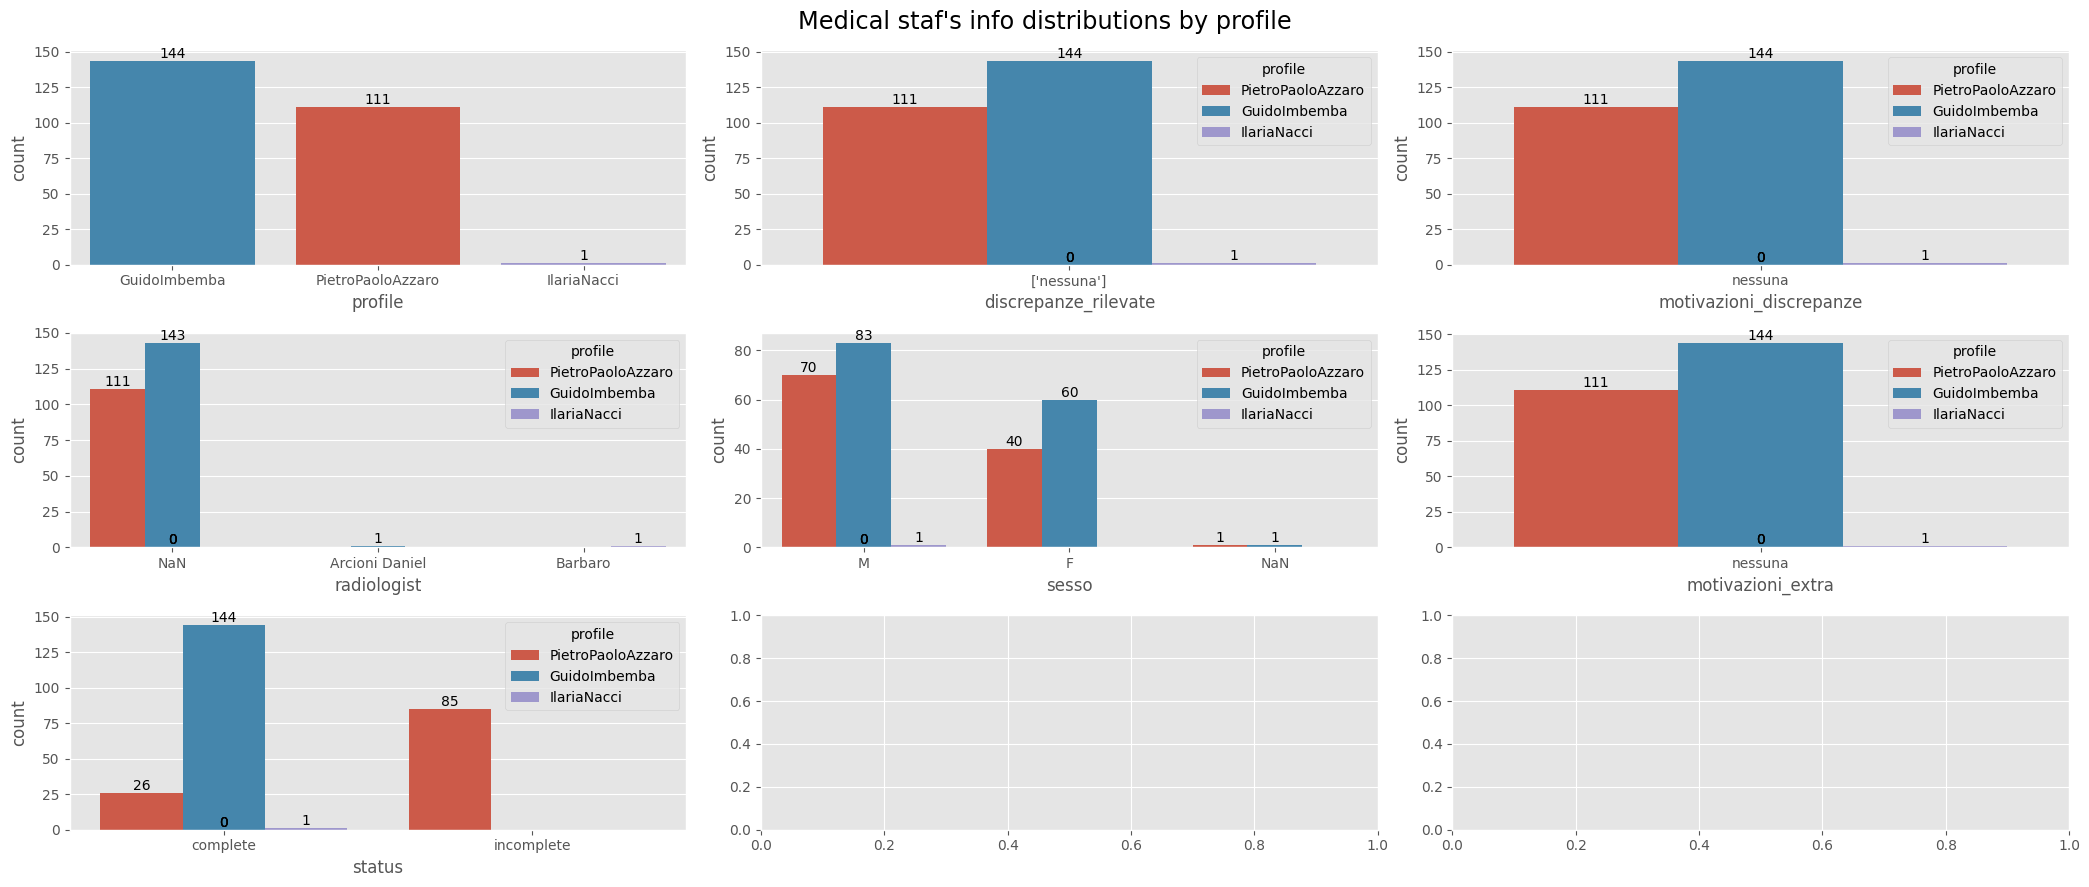

In [98]:
columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
#columns_plot = ['profile', 'status']
hue_column = 'profile'

data_x = pd.concat([data_plot, data_ilaria])
include_ilaria = True
print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions by profile", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]
    if include_ilaria:
        sns.countplot(data=data_x, x=col, order=data_x[col].value_counts().index, ax=ax, hue=hue_column)
    else:
        sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    columns = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
    print(f'{len(columns) = }\n')
    for col in columns:
        print(data_clean[col].value_counts().to_frame().T)
        print("\n")

Ilaria told us to exclude Pietro's records. We also see how there is only one status = incomplete records of Guido.  

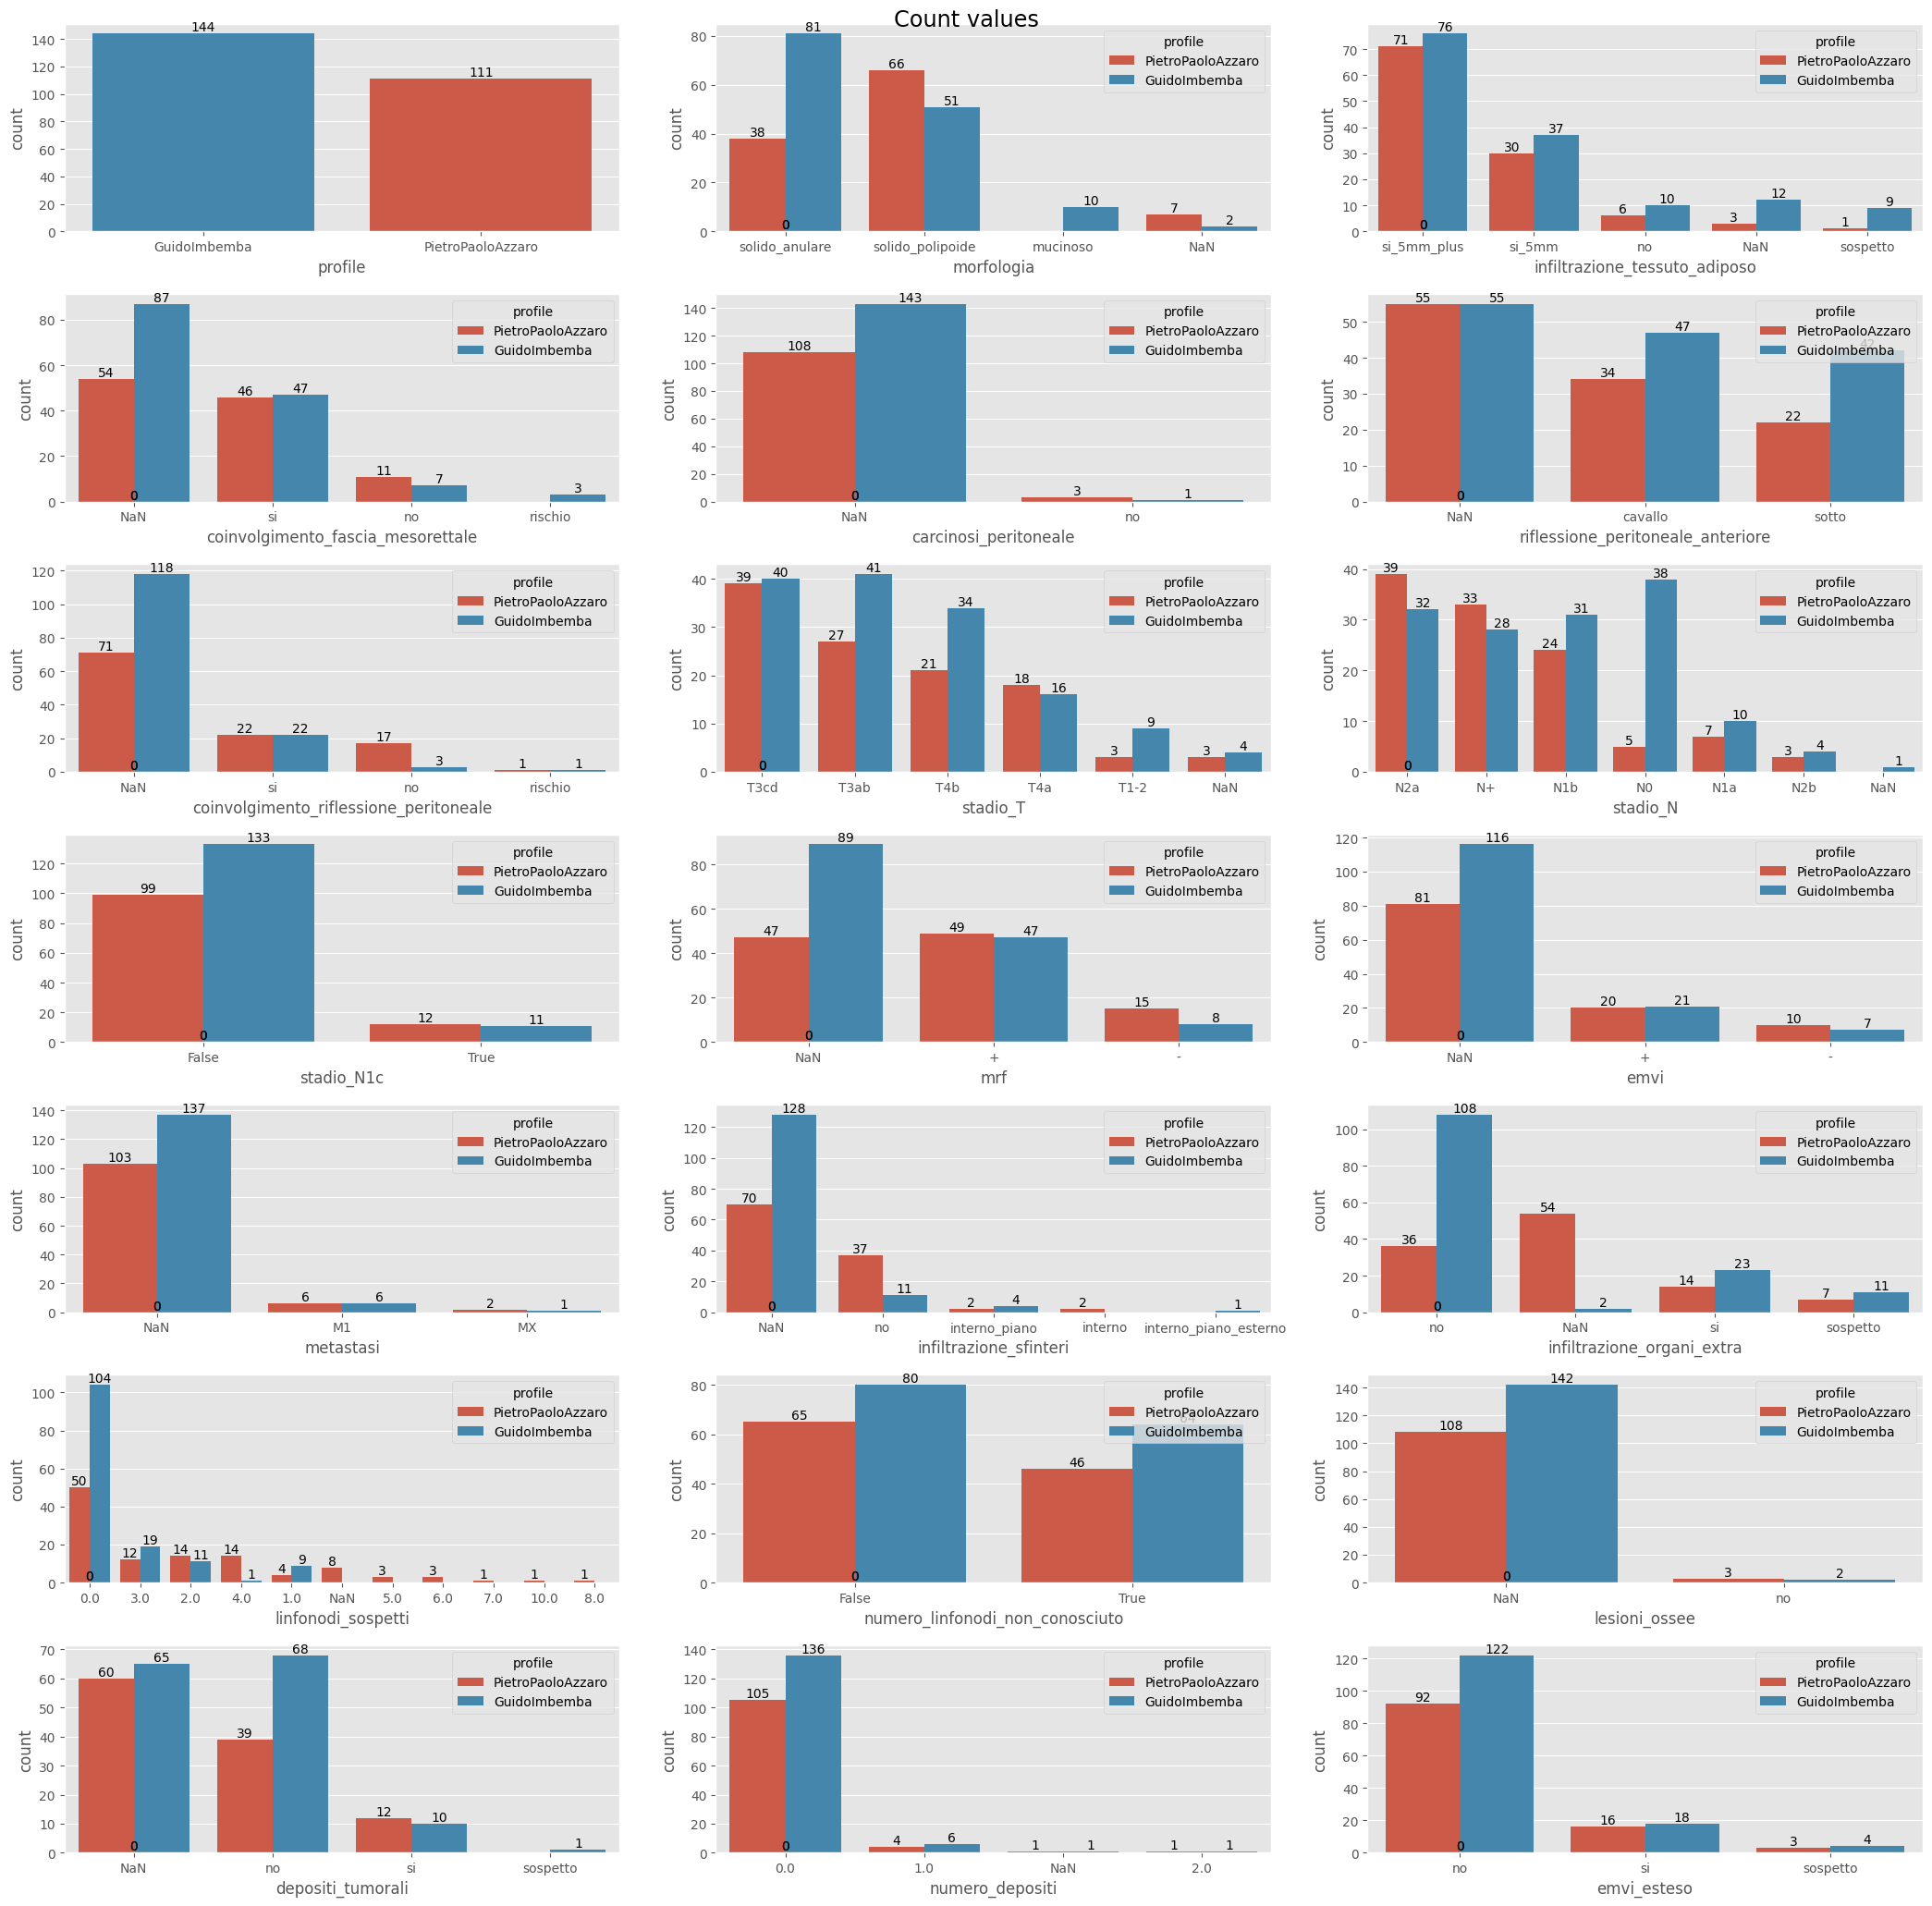

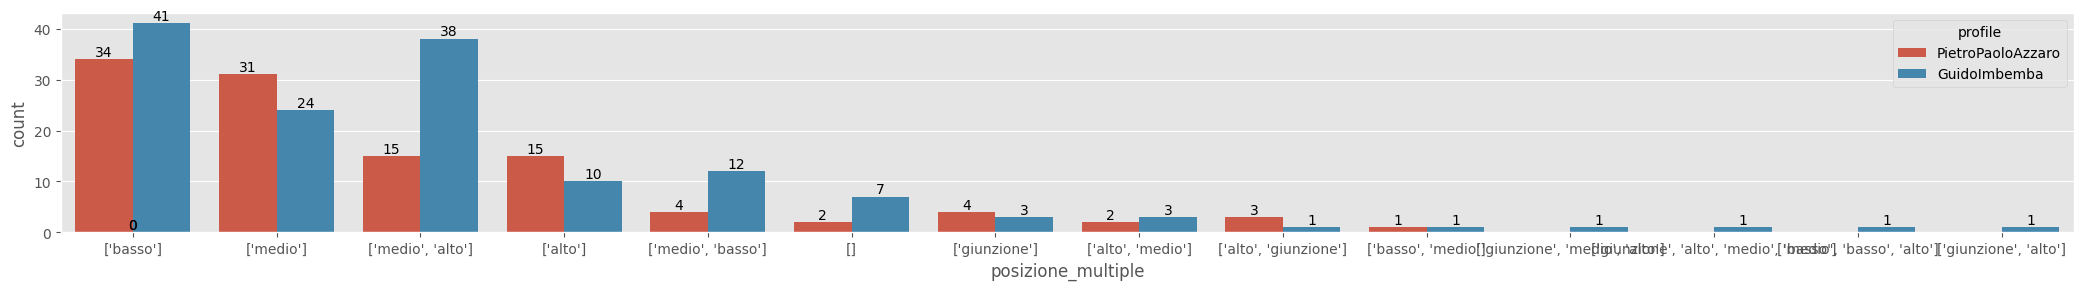

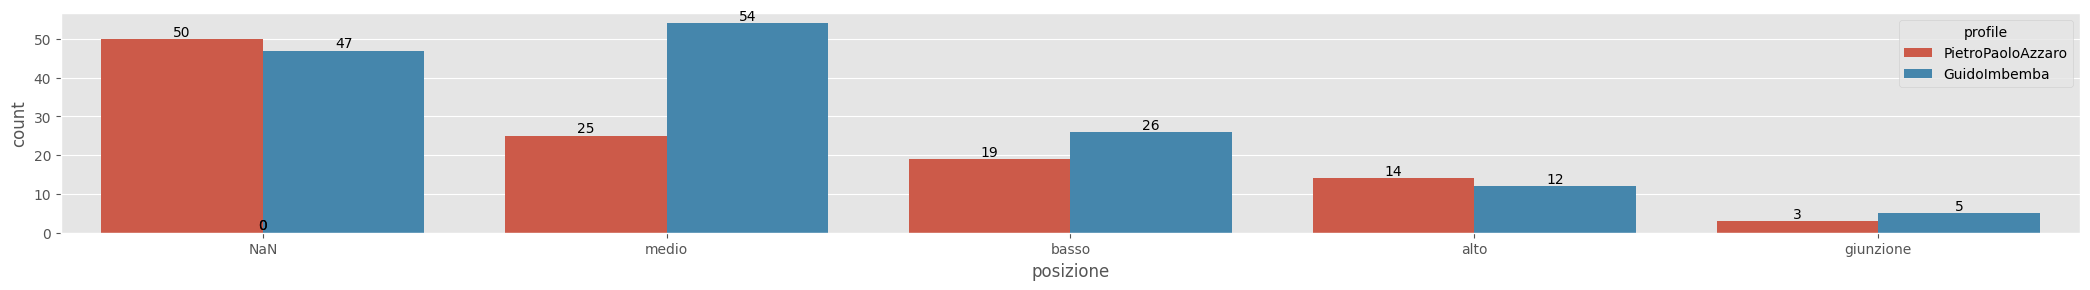

In [100]:
columns_plot = ['profile', 'morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = 'depositi_tumorali'
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione', order=data_plot['posizione'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**We see many anomalies between Guido and Pietro style of annotation. For this reason and also for what Ilaria told us, we will take into consideration only reports annotated by Guido**

# Guido's rows

In [101]:
data_clean_guido = data_clean[data_clean['profile'] == 'GuidoImbemba'].copy(deep=True)
data_clean_guido.reset_index(inplace=True, drop=True)
data_plot = data_clean_guido.fillna('NaN')

print(data_clean_guido.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      144 non-null    int64  
 1   profile                                 144 non-null    object 
 2   discrepanze_rilevate                    144 non-null    object 
 3   motivazioni_discrepanze                 144 non-null    object 
 4   radiologist                             1 non-null      object 
 5   patient_id                              144 non-null    int64  
 6   sesso                                   143 non-null    object 
 7   data_nascita                            144 non-null    object 
 8   interpretazioni                         59 non-null     object 
 9   report_text                             144 non-null    object 
 10  morfologia                              142 non-null    object

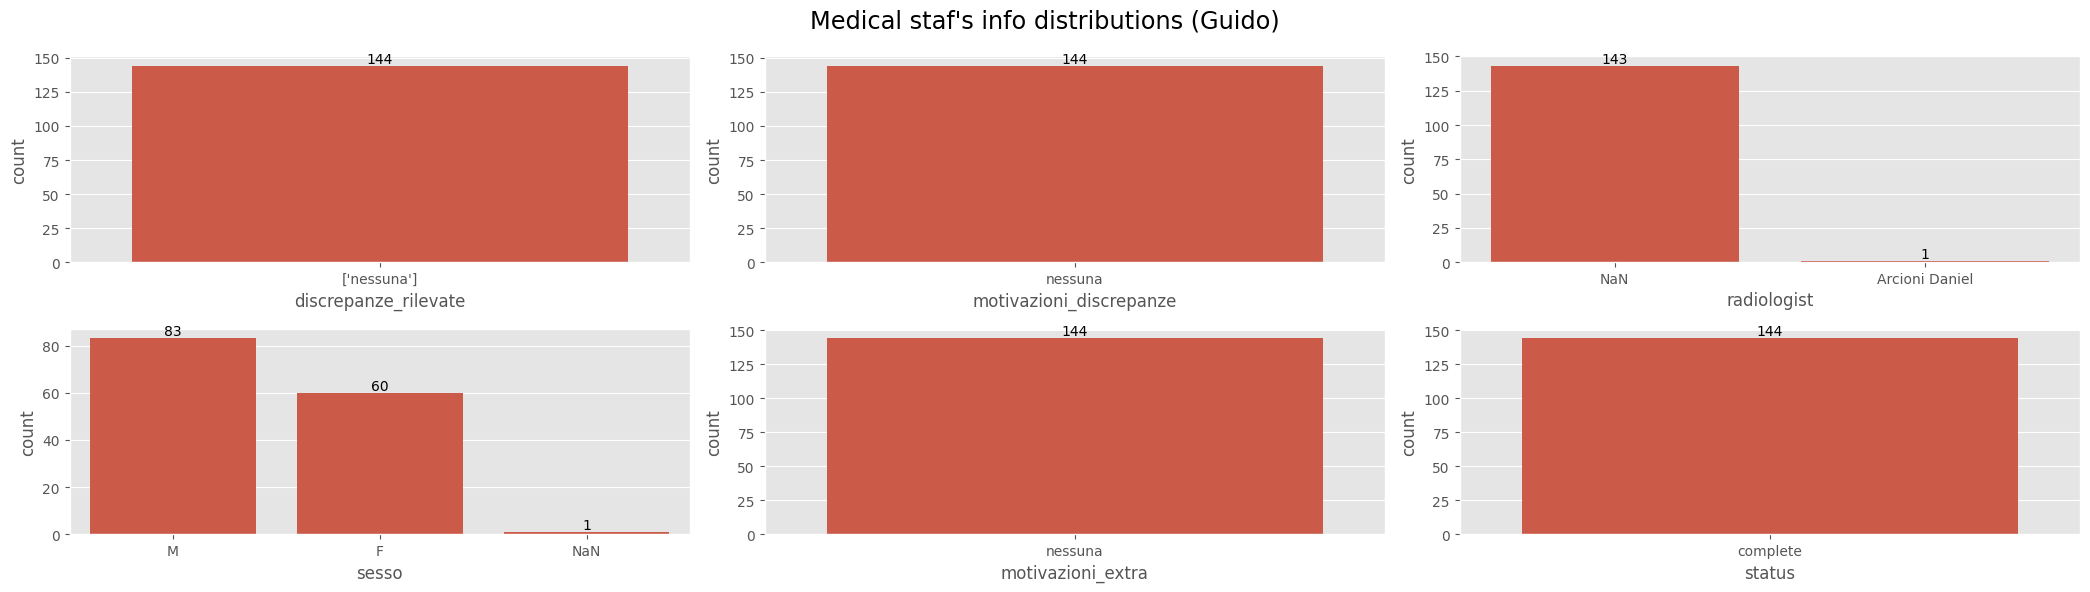

In [103]:
columns_plot = ['discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']

print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]    
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    print(f'{len(columns_plot) = }\n')
    for col in columns_plot:
        print(data_plot[col].value_counts().to_frame().T)
        print("\n")

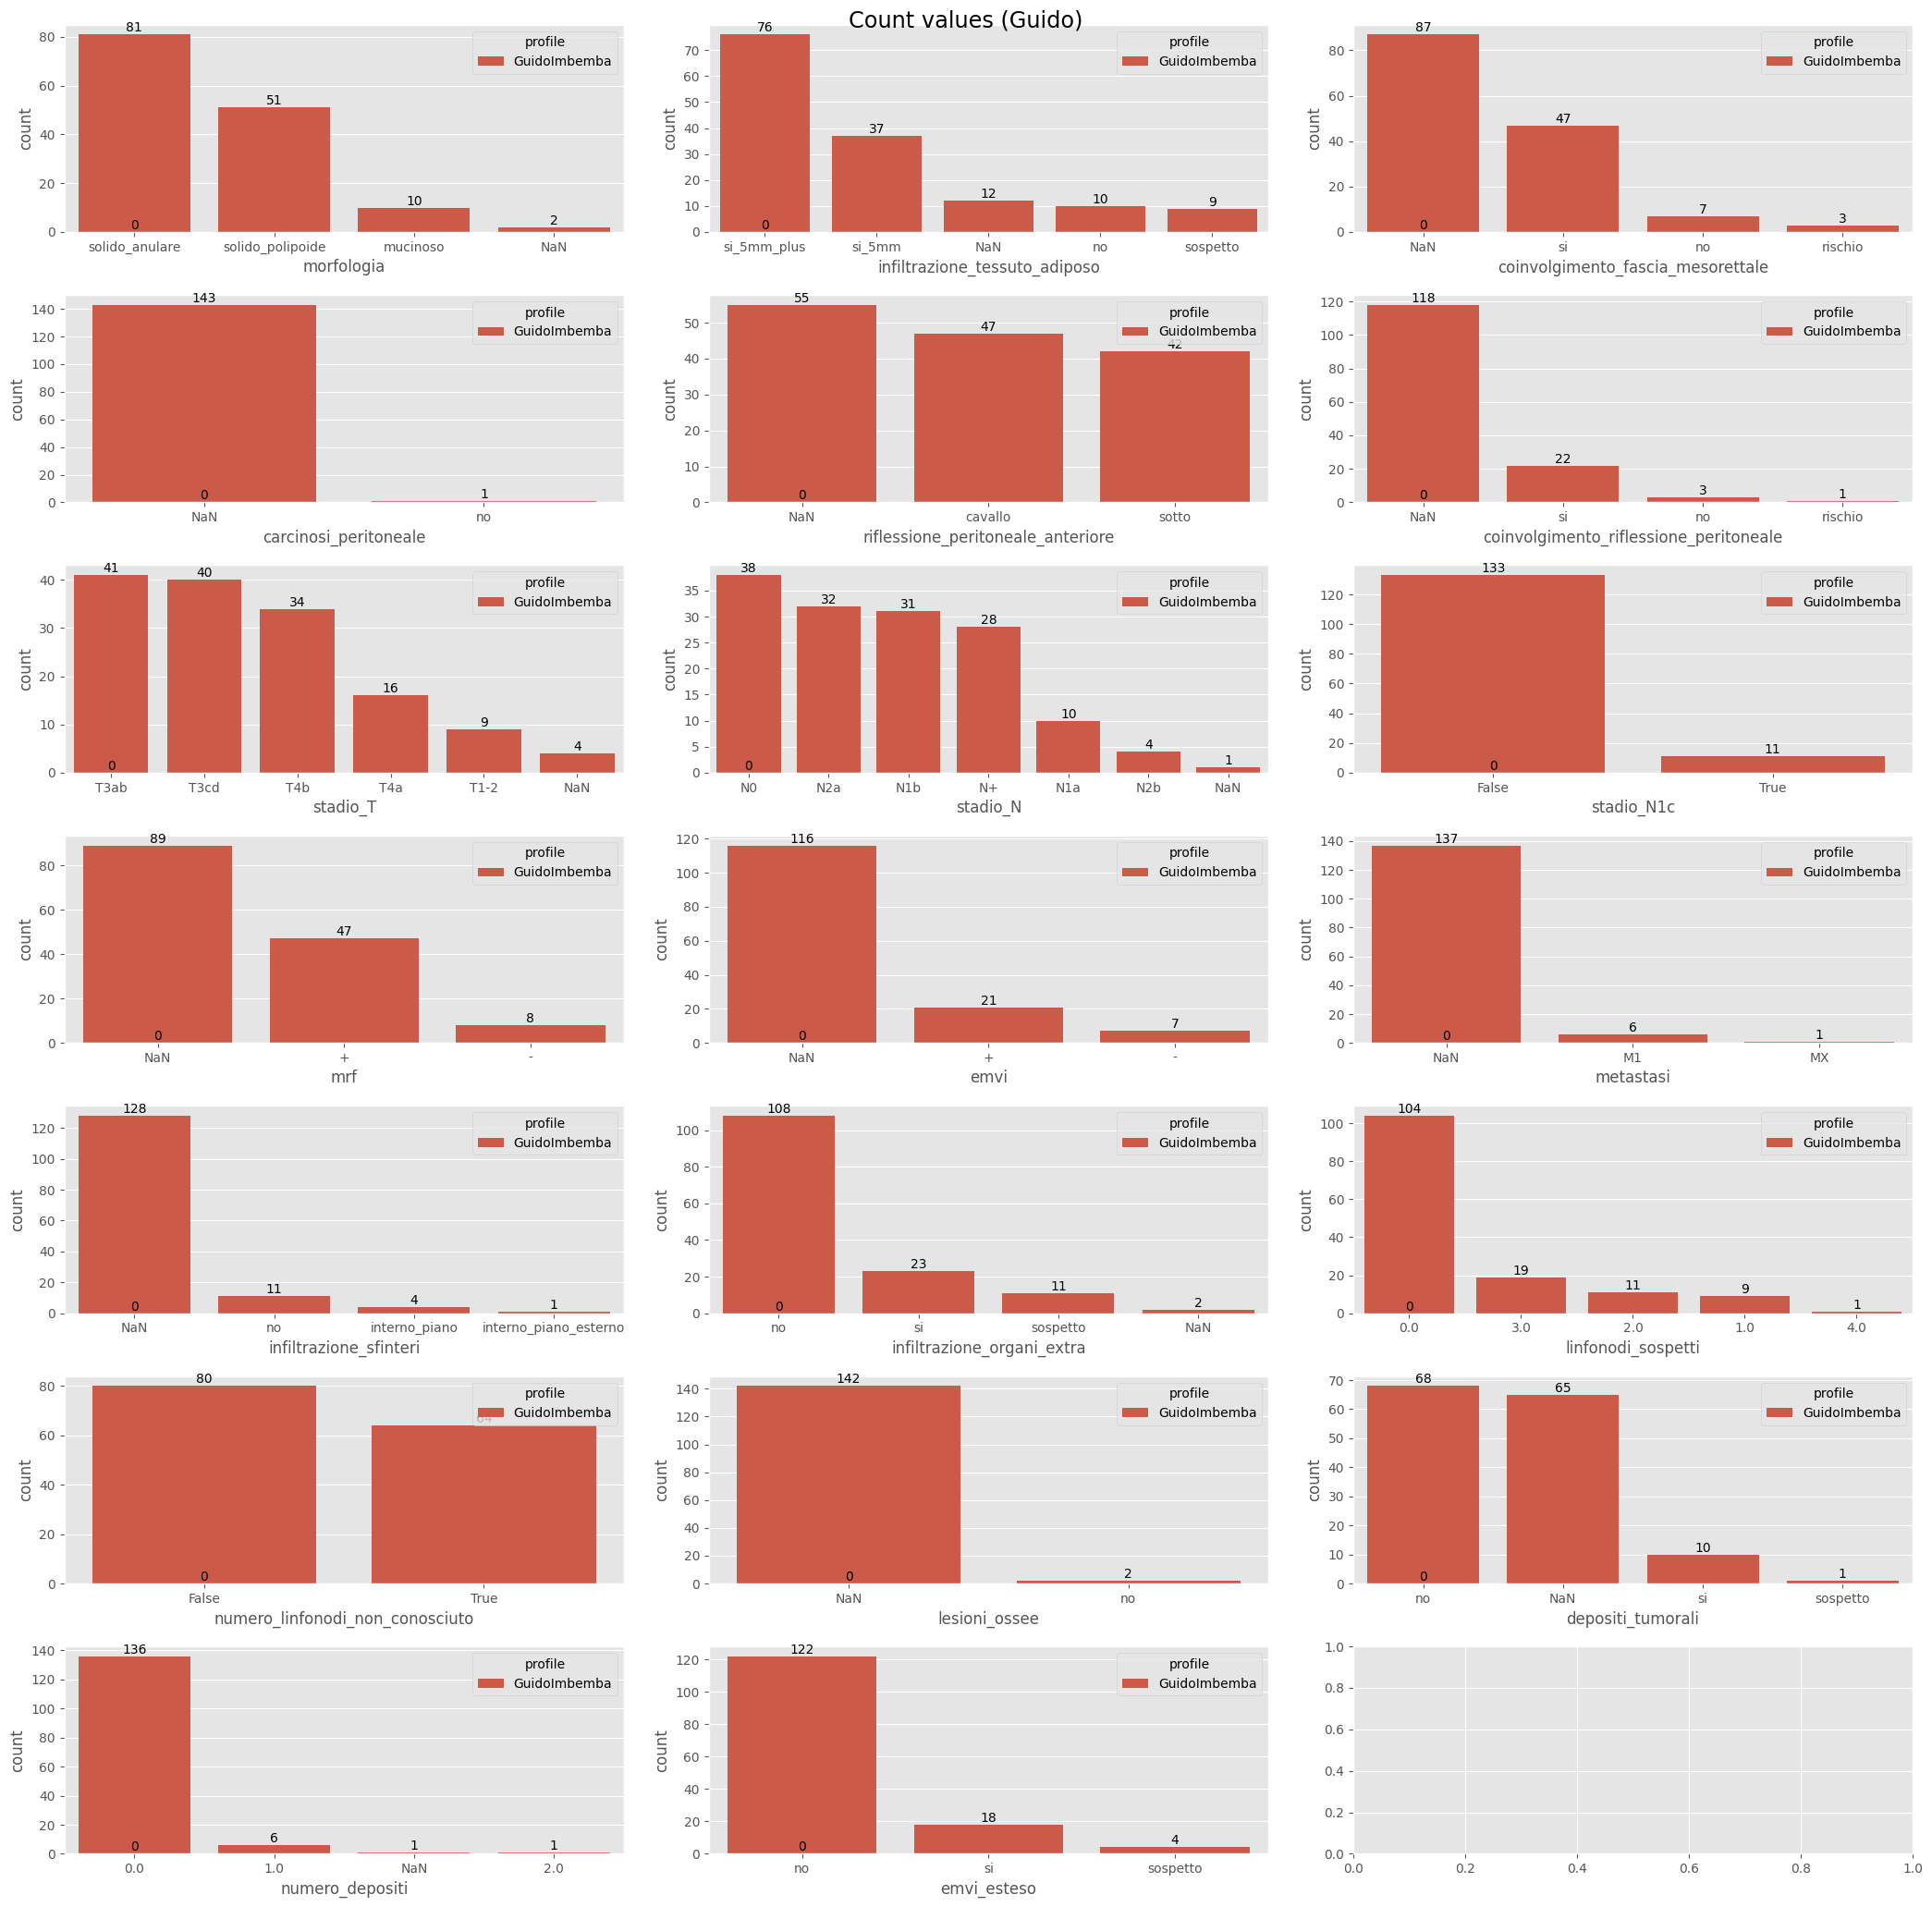

In [104]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

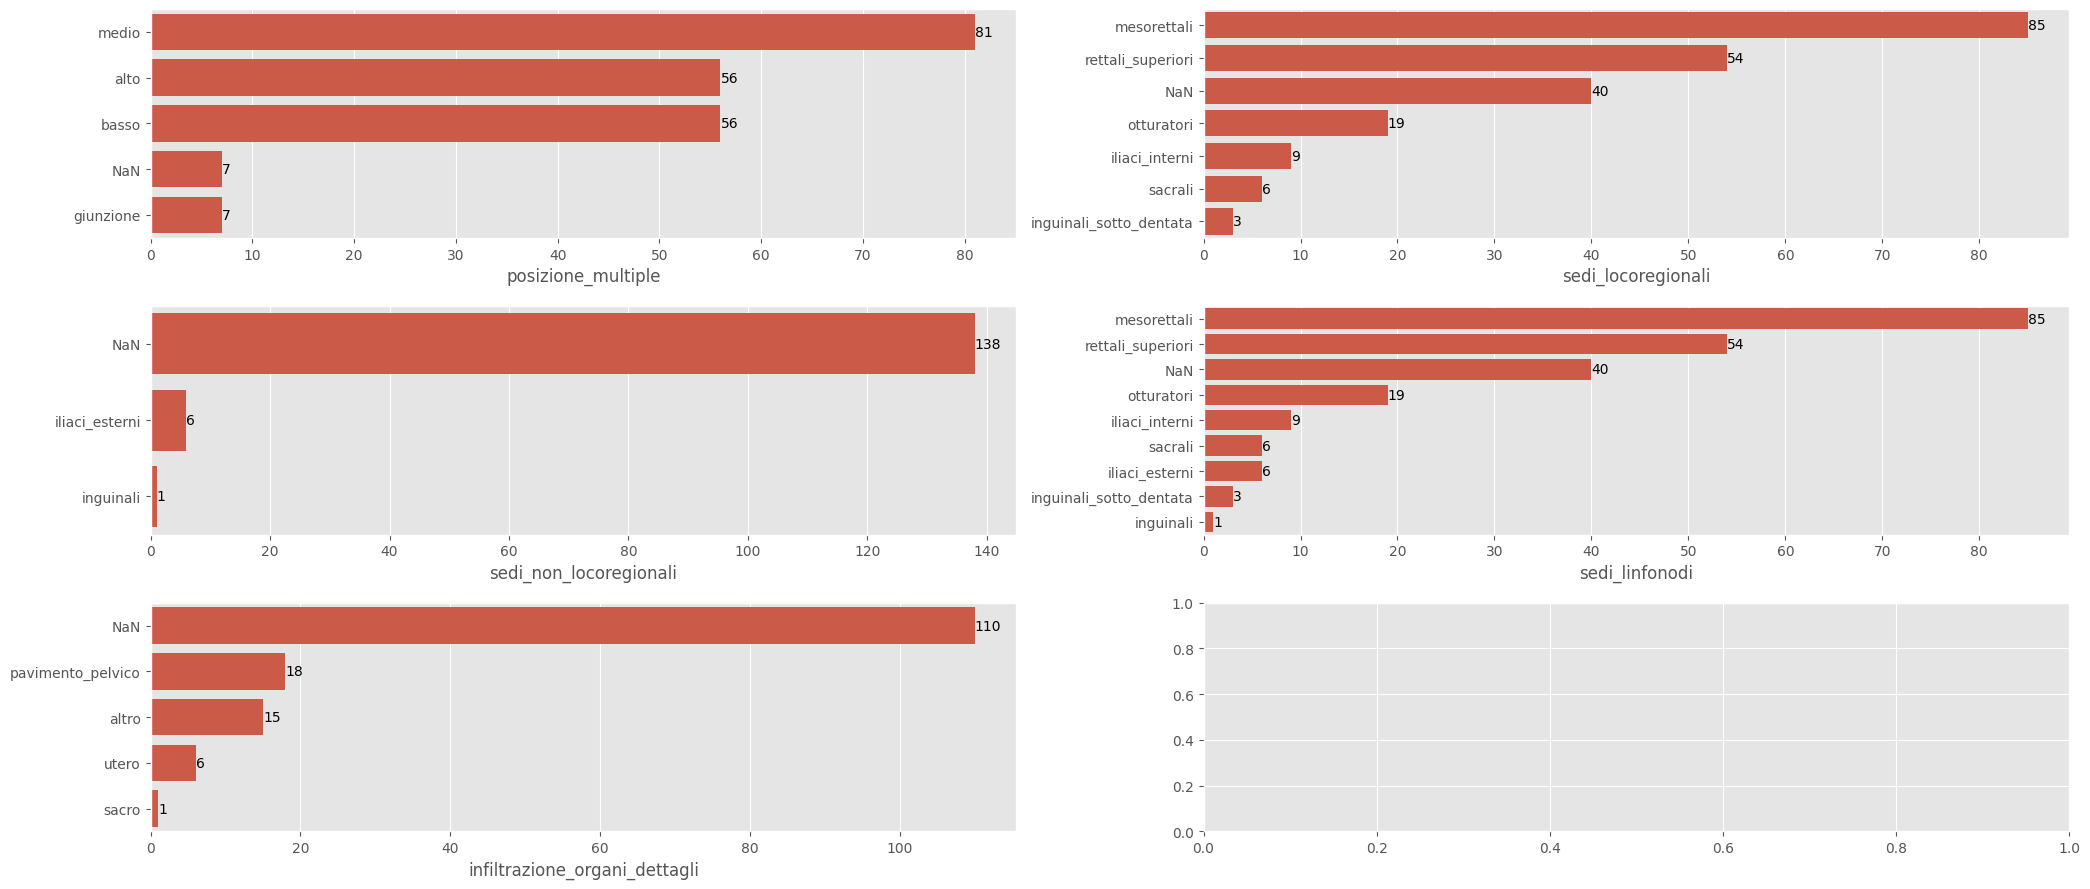

In [105]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
            
# Dettagli organi
dettagli_organi = {'NaN'}
altri_organi = set()
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN').value_counts().index:
    if s != 'NaN' and s != 'nan':
        d = ast.literal_eval(s)
        #print('---')
        dettagli_organi.update(d.keys())
        if 'altro' in d:
            altri_organi.add(d['altro'])
            
dettagli_organi_counts = {val: 0 for val in dettagli_organi}
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    if s == 'NaN' or s == 'nan':
        dettagli_organi_counts['NaN'] += 1
    else:
        d = ast.literal_eval(s)
        for key in dettagli_organi:
            if key in d:
                dettagli_organi_counts[key] += 1

counts['infiltrazione_organi_dettagli'] = dettagli_organi_counts
columns.append('infiltrazione_organi_dettagli')
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

Idea: uniamo sedi locoregionali e non locoregionali e manteniamo solo alcune classi: mesorettali, rettali_superiori, NaN, otturatori, iliaci. I restanti li metteremo in "altro".

Per quanto riguarda i dettagli dell'infiltrazione organi, teniamo solo le classi NaN, pavimento_pelvico, altro.

# Aggregazione / modifica delle colonne

In [106]:
palette_corrente = plt.rcParams['axes.prop_cycle'].by_key()['color']
print(palette_corrente)
display(sns.color_palette(palette_corrente))
new_color = palette_corrente[-2]

['#E24A33', '#348ABD', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#FFB5B8']


[(0.8862745098039215, 0.2901960784313726, 0.2),
 (0.20392156862745098, 0.5411764705882353, 0.7411764705882353),
 (0.596078431372549, 0.5568627450980392, 0.8352941176470589),
 (0.4666666666666667, 0.4666666666666667, 0.4666666666666667),
 (0.984313725490196, 0.7568627450980392, 0.3686274509803922),
 (0.5568627450980392, 0.7294117647058823, 0.25882352941176473),
 (1.0, 0.7098039215686275, 0.7215686274509804)]

In [107]:
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    dettagli = []
    if s == 'NaN':
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        d = ast.literal_eval(s)
        if 'pavimento_pelvico' in d:
            dettagli.append('pavimento_pelvico')
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            dettagli.append('altro')
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data_clean_guido.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new

#print(data_clean_guido.infiltrazione_organi_dettagli.value_counts())

# Sedi linfonodi
sedi_linfonodi_new = []
for s in data_clean_guido.sedi_linfonodi:
    sedi = ast.literal_eval(s)
    sedi_new = set()
    for sede in sedi:
        if sede in ['mesorettali', 'rettali_superiori', 'otturatori']:
            sedi_new.add(sede)
        elif sede in ['iliaci_comuni', 'iliaci_interni', 'iliaci_esterni']:
            sedi_new.add('iliaci')
        else:
            sedi_new.add('altro')
    sedi_linfonodi_new.append(str(list(sedi_new)))
data_clean_guido.loc[:, 'sedi_linfonodi'] = sedi_linfonodi_new
#print(data_clean_guido.sedi_linfonodi.value_counts())

# Coinvolgimento fascia mesorettale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_fascia_mesorettale'] == 'rischio', 'coinvolgimento_fascia_mesorettale'] = 'si'
#print(data_clean_guido.coinvolgimento_fascia_mesorettale.value_counts())

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_riflessione_peritoneale'] == 'rischio', 'coinvolgimento_riflessione_peritoneale'] = 'si'
#print(data_clean_guido.coinvolgimento_riflessione_peritoneale.value_counts())

# Infiltrazione sfinteri. Trasformiamo la posizione in si. per otenere una classe (si/no/NaN)
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano_esterno', 'infiltrazione_sfinteri'] = 'si'
#print(data_clean_guido.infiltrazione_sfinteri.value_counts())

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['emvi_esteso'] == 'sospetto', 'emvi_esteso'] = 'si'
#print(data_clean_guido.emvi_esteso.value_counts())

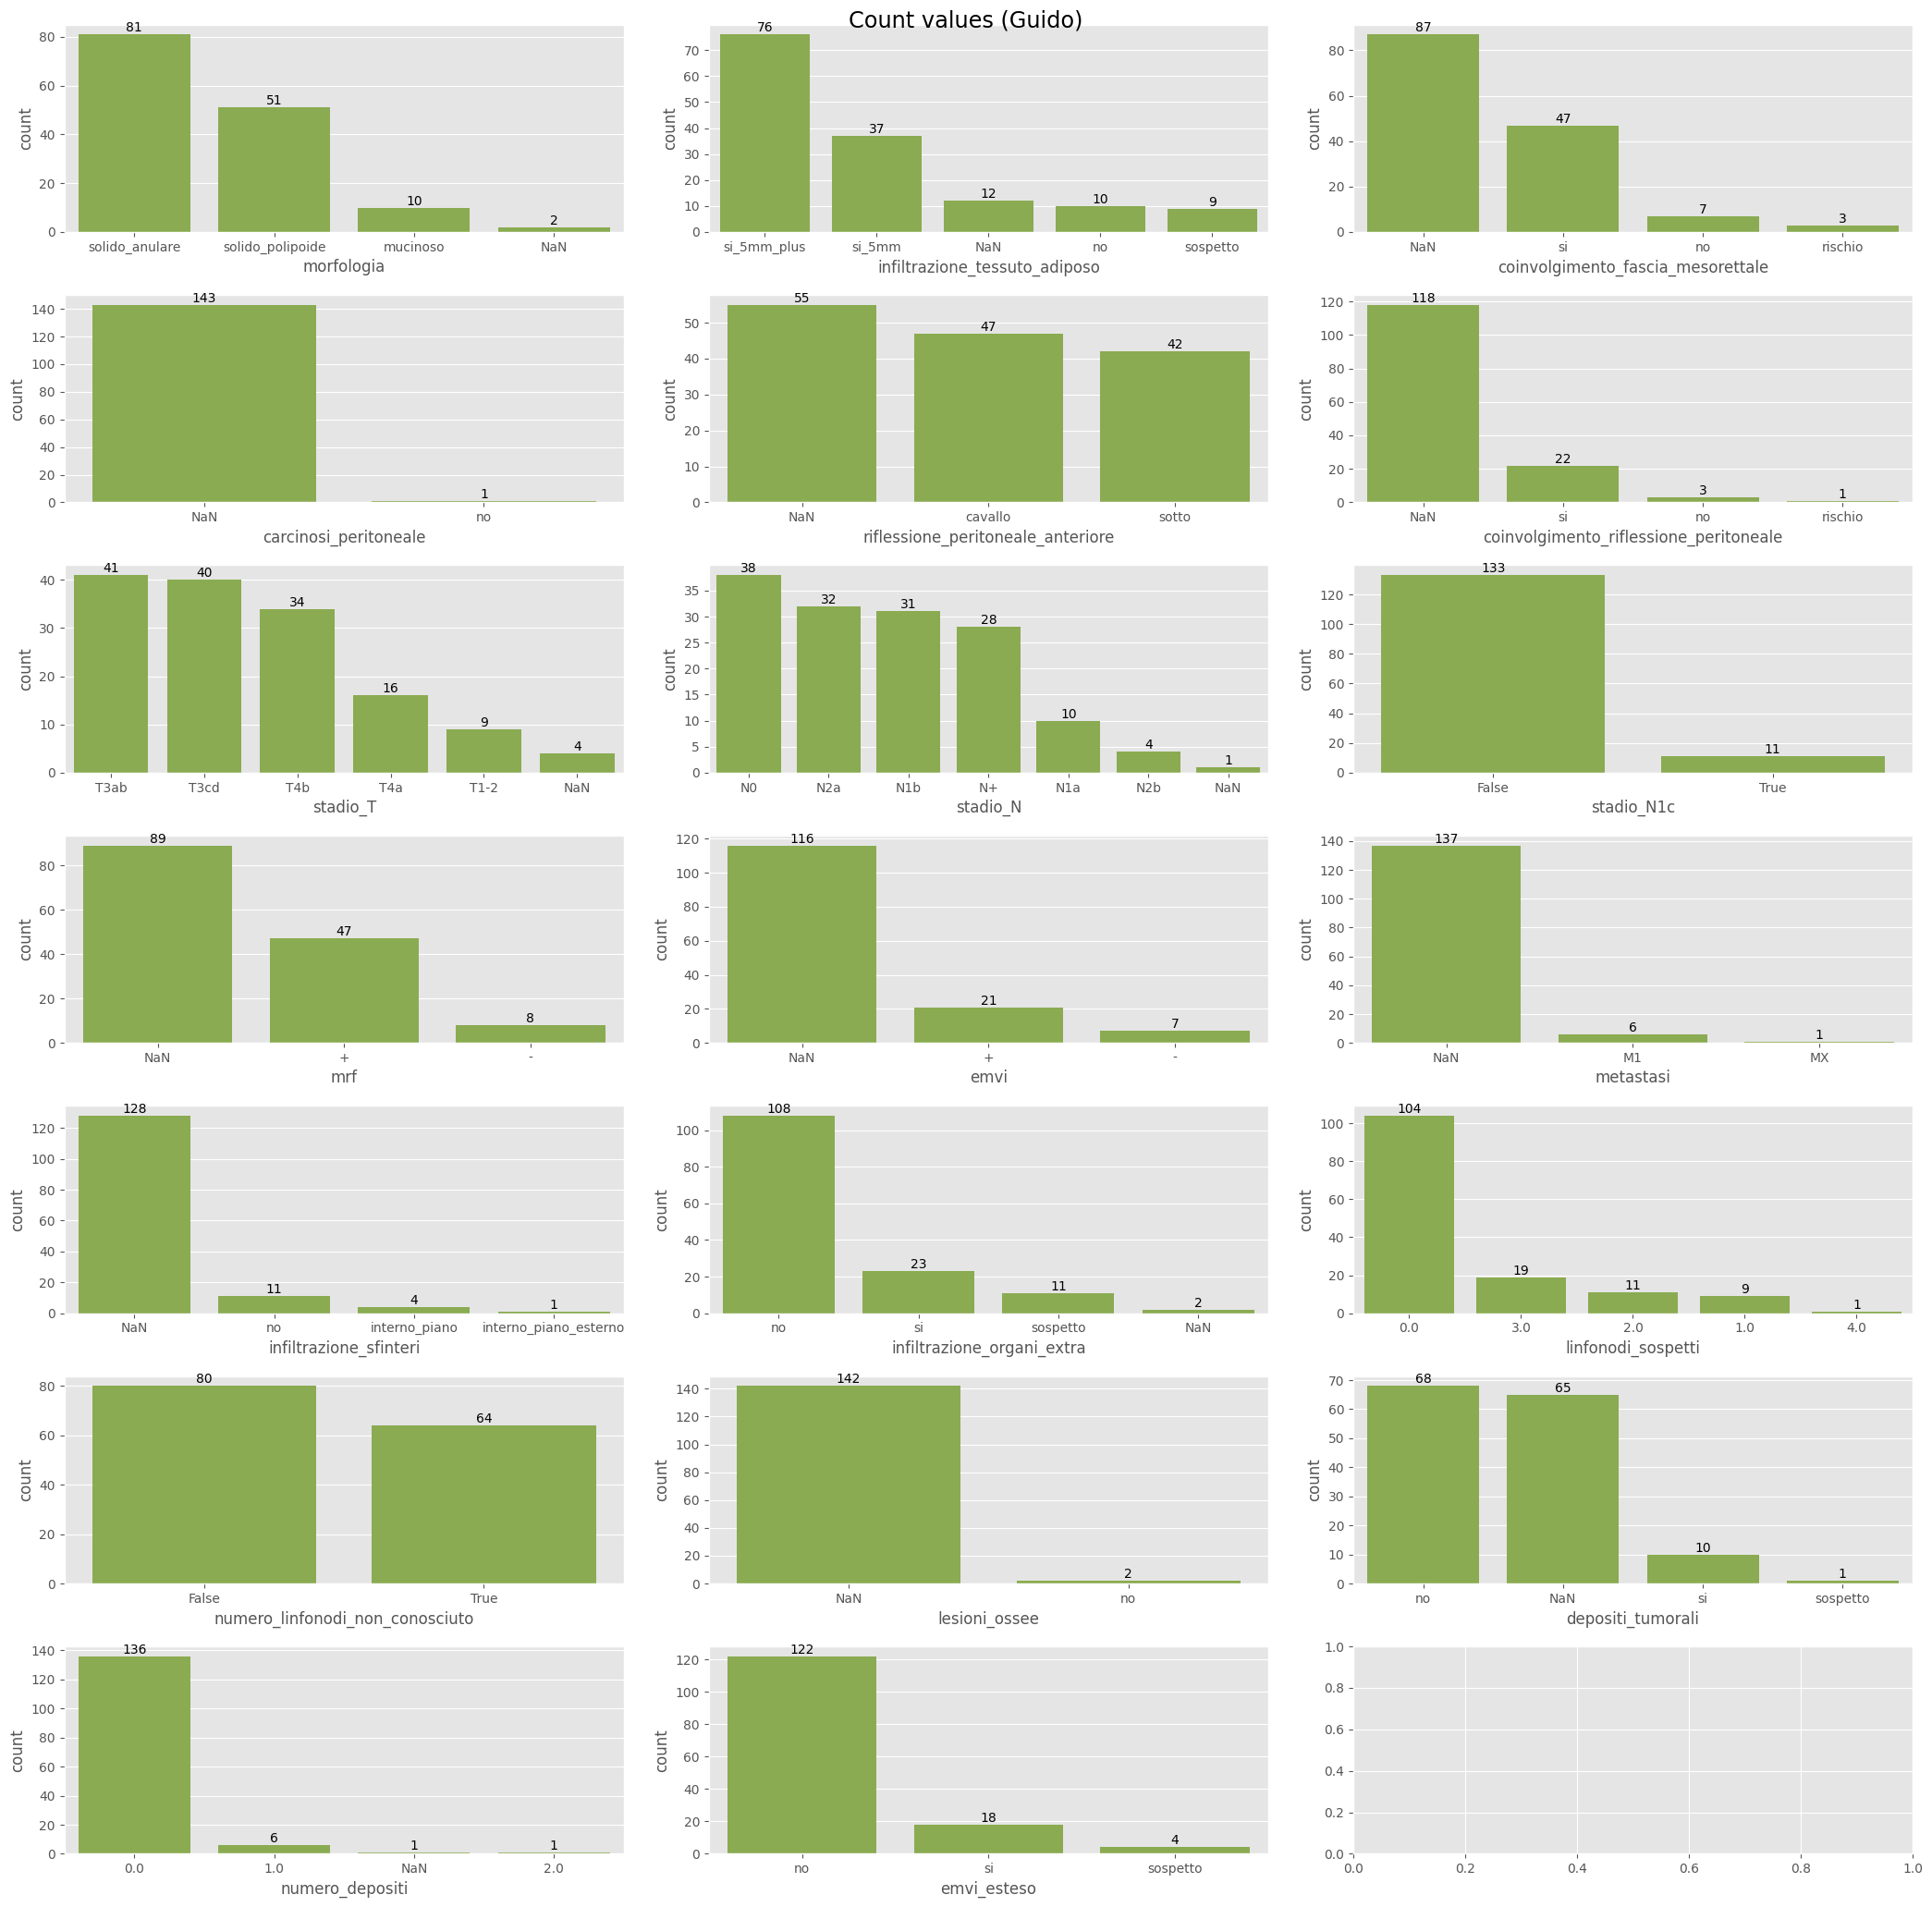

In [108]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, color=new_color)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

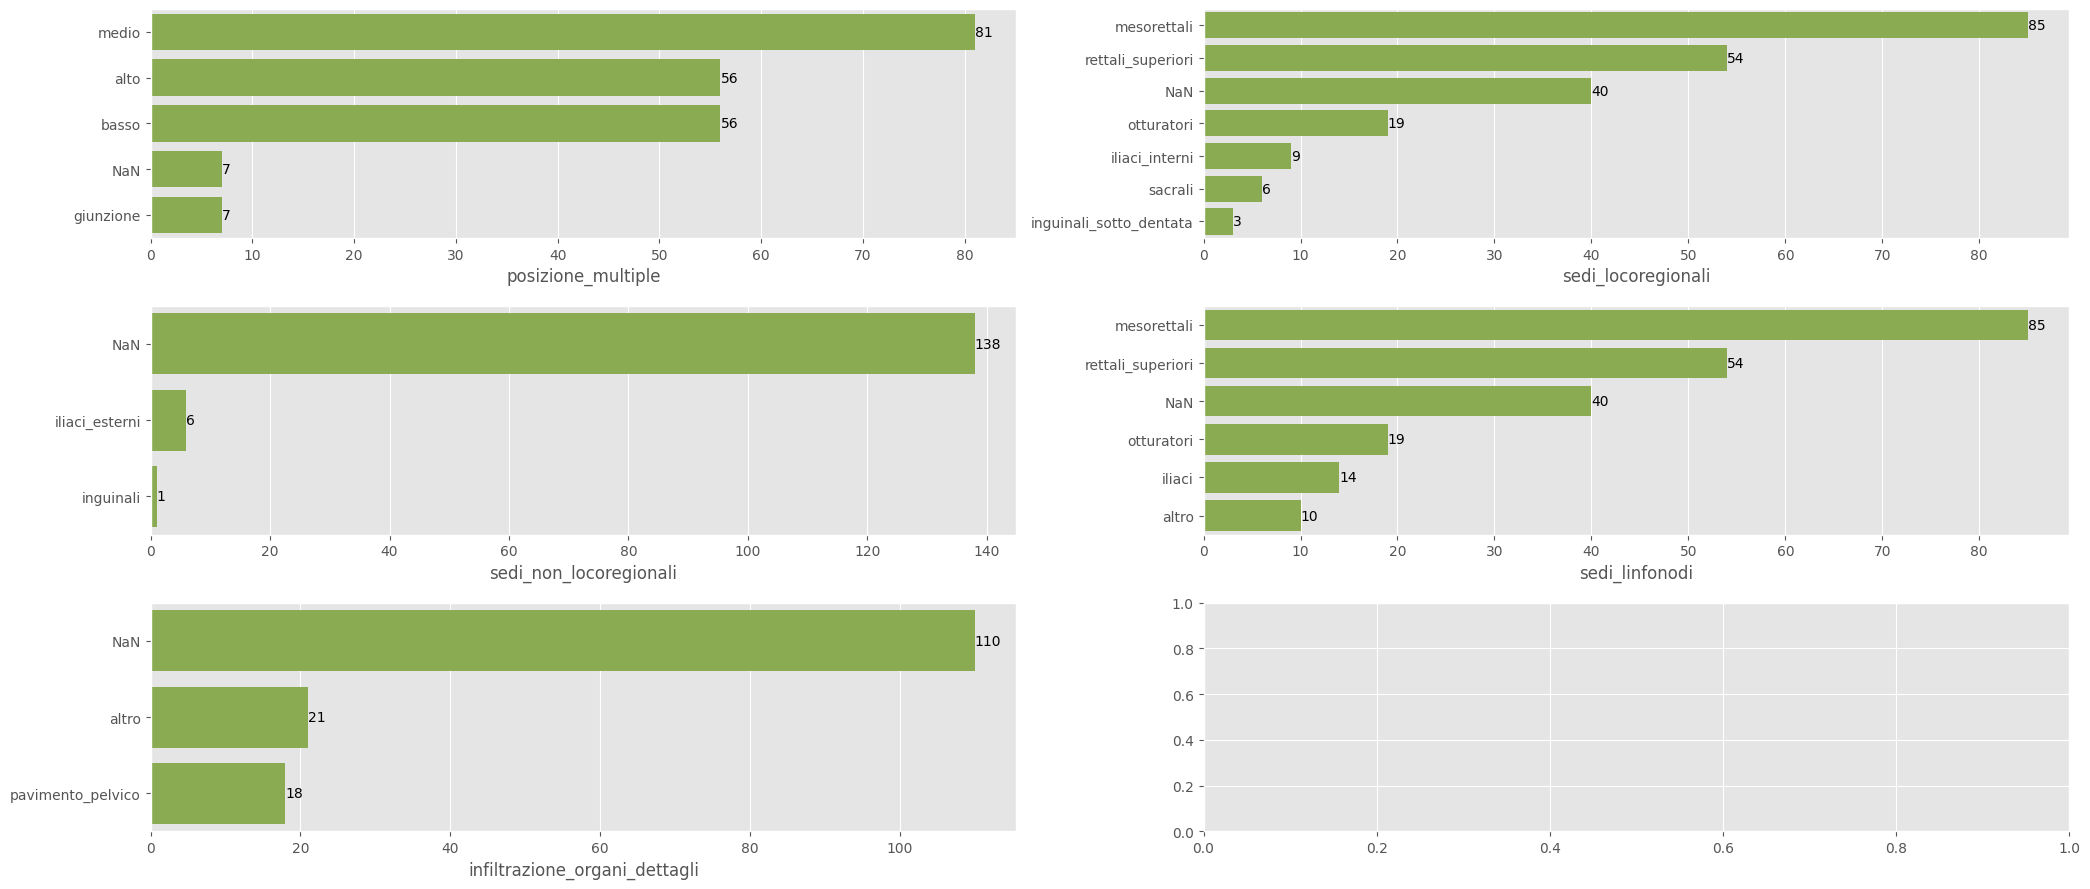

In [109]:
data_plot = data_clean_guido.fillna('NaN')

# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi', 'infiltrazione_organi_dettagli']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation, color=new_color)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

## Colonne target numeriche

In [110]:
data_clean_guido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      144 non-null    int64  
 1   profile                                 144 non-null    object 
 2   discrepanze_rilevate                    144 non-null    object 
 3   motivazioni_discrepanze                 144 non-null    object 
 4   radiologist                             1 non-null      object 
 5   patient_id                              144 non-null    int64  
 6   sesso                                   143 non-null    object 
 7   data_nascita                            144 non-null    object 
 8   interpretazioni                         59 non-null     object 
 9   report_text                             144 non-null    object 
 10  morfologia                              142 non-null    object

In [111]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'numero_depositi']

In [112]:
data_clean_guido[colonne_target_numeriche].describe().T

,count,mean,std,min,25%,50%,75%,max
ore_inizio,57.0,9.368421,3.538722,1.0,6.00,12.0,12.00,12.0
ore_fine,57.0,10.192982,3.492025,1.0,11.00,12.0,12.00,12.0
dimensione_dll,12.0,42.250000,26.330504,15.0,21.50,40.0,49.75,105.0
dimensione_dap,9.0,53.111111,32.643699,25.0,31.00,38.0,53.00,120.0
spessore_parietale,25.0,20.280000,13.030477,7.0,13.00,15.0,22.00,60.0
estensione_cranio_caudale,135.0,48.533333,17.460317,18.0,35.50,47.0,55.00,130.0
distanza_oai,132.0,44.954545,29.293947,0.0,23.75,48.5,65.00,120.0
distanza_minima_fascia_ore,7.0,6.000000,4.760952,1.0,2.00,5.0,10.00,12.0
linfonodi_sospetti,144.0,0.638889,1.125739,0.0,0.00,0.0,1.00,4.0
numero_depositi,143.0,0.055944,0.259366,0.0,0.00,0.0,0.00,2.0


escludere le segenti colonne perchè hanno troppi valori nulli:
- ore_inizio
- ore_fine
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

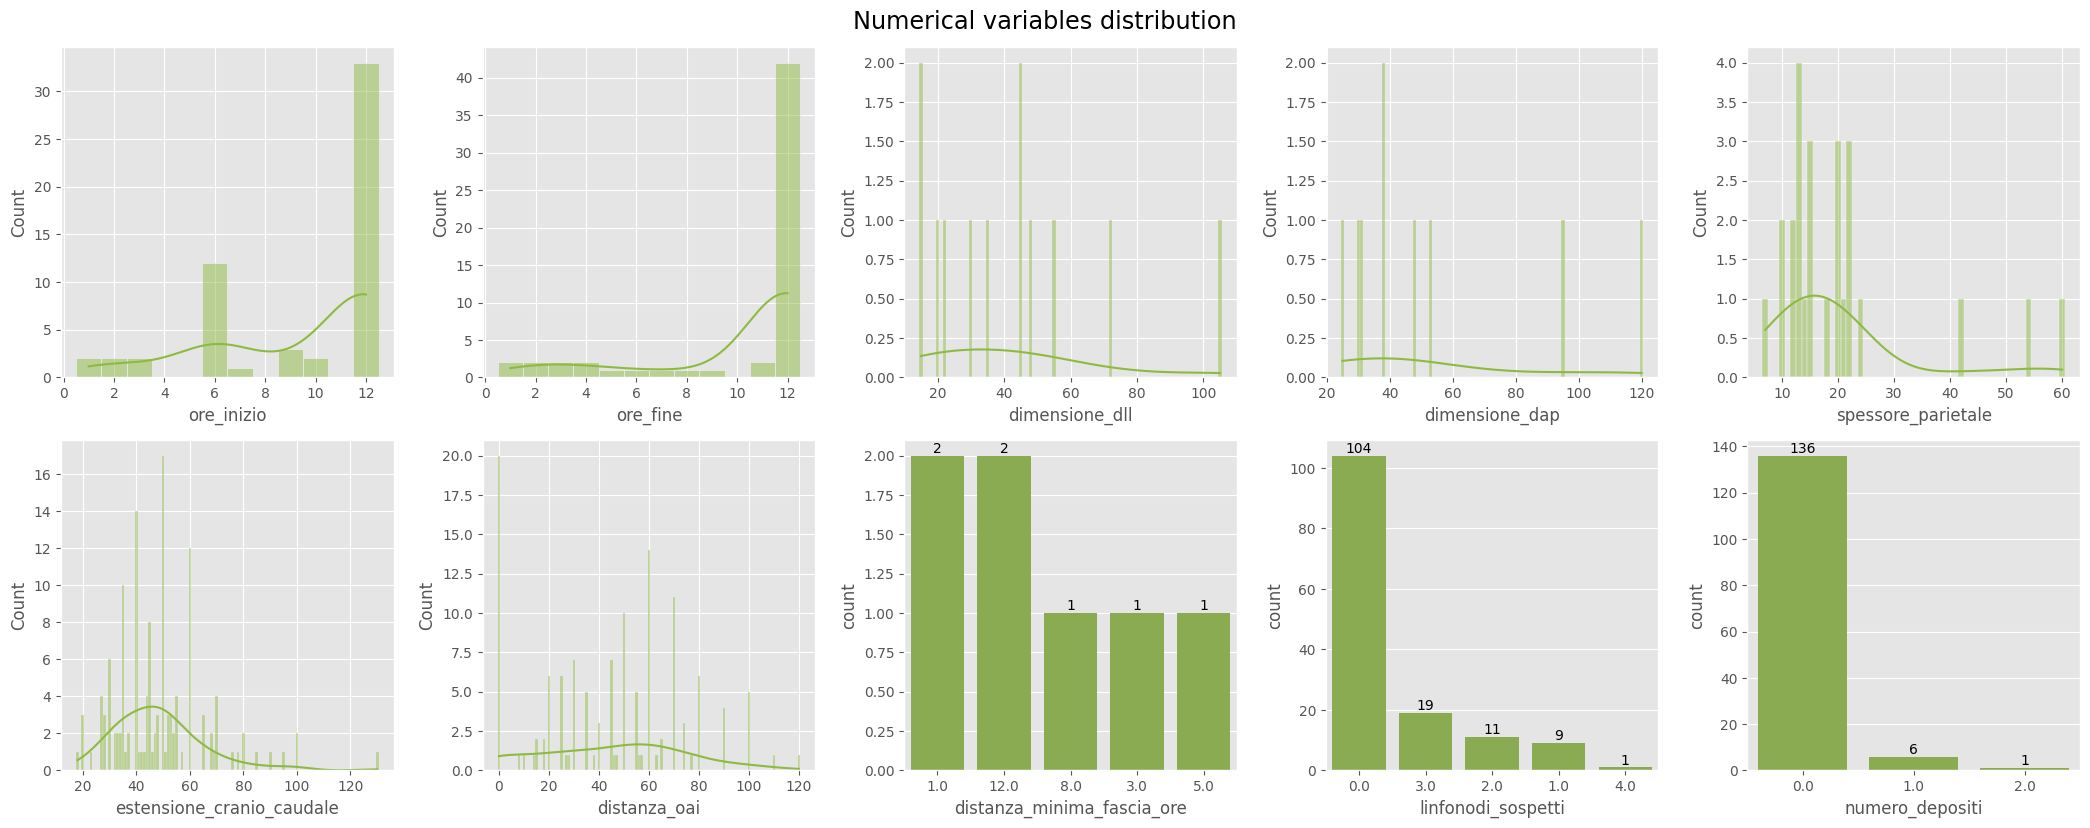

In [113]:
n_columns = 5
n_rows, r = divmod(len(colonne_target_numeriche), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*21/n_columns))
fig.suptitle("Numerical variables distribution", fontsize='xx-large')

for i, col in enumerate(colonne_target_numeriche):
    ax=axes[i//n_columns][i%n_columns]
    if len(data_clean_guido[col].value_counts()) > 5:
        sns.histplot(data=data_clean_guido, x=col, ax=ax, color=new_color, discrete=True, stat='count', kde=True)
    else:
        sns.countplot(data=data_clean_guido, x=col, order=data_clean_guido[col].value_counts().index, ax=ax, color=new_color)
        # Add values on top of bars
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()